In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train_df = pd.read_csv('/content/train house.csv')
train_df.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


In [ ]:
test_df = pd.read_csv('/content/test house.csv')
test_df.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE
0,Owner,0,0,1,BHK,545.171340,1,1,"Kamrej,Surat",21.262000,73.047700
1,Dealer,1,1,2,BHK,800.000000,0,0,"Panvel,Lalitpur",18.966114,73.148278
2,Dealer,0,0,2,BHK,1257.096513,1,1,"New Town,Kolkata",22.592200,88.484911
3,Dealer,0,0,3,BHK,1400.329489,1,1,"Kalwar Road,Jaipur",26.988300,75.584600
4,Owner,0,0,1,BHK,430.477830,1,1,"Mai Mandir,Nadiad",22.700000,72.870000


### Price Distribution ###


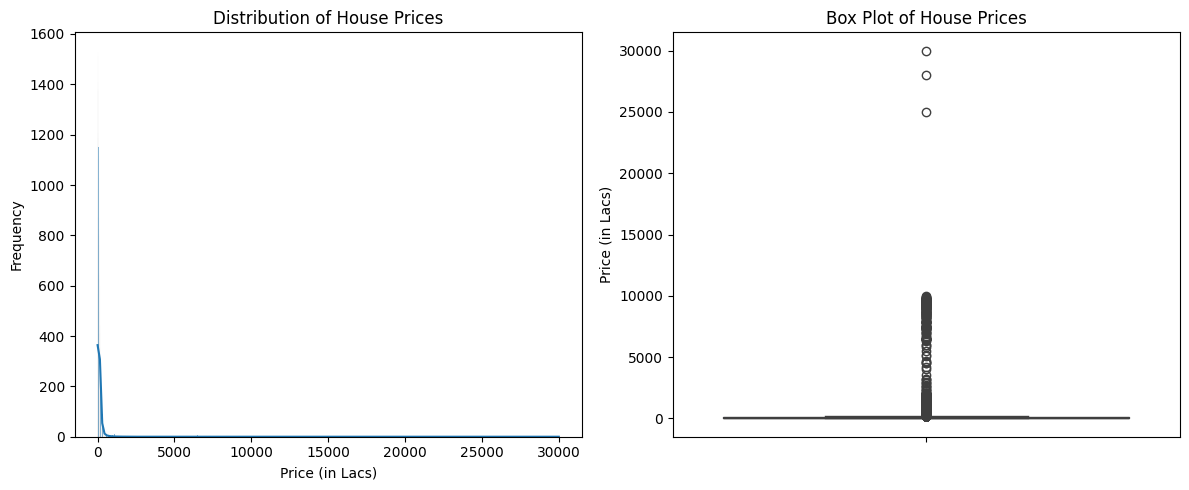


### Missing Values in Training Data ###
No missing values in the training data.

### Missing Values in Test Data ###
No missing values in the test data.


In [ ]:
print("### Price Distribution ###")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(train_df['TARGET(PRICE_IN_LACS)'], kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price (in Lacs)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=train_df['TARGET(PRICE_IN_LACS)'])
plt.title('Box Plot of House Prices')
plt.ylabel('Price (in Lacs)')

plt.tight_layout()
plt.show()

print("\n### Missing Values in Training Data ###")
missing_train = train_df.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
if missing_train.empty:
    print("No missing values in the training data.")
else:
    print(missing_train)

print("\n### Missing Values in Test Data ###")
many_missing_test = test_df.isnull().sum()
many_missing_test = many_missing_test[many_missing_test > 0].sort_values(ascending=False)
if many_missing_test.empty:
    print("No missing values in the test data.")
else:
    print(many_missing_test)

In [ ]:
initial_rows = train_df.shape[0]
train_df.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - train_df.shape[0]
print(f"Removed {duplicates_removed} duplicate rows from the training data.")


# Remove extreme outliers in TARGET(PRICE_IN_LACS)
# Calculate Q1, Q3 and IQR for the target variable
Q1 = train_df['TARGET(PRICE_IN_LACS)'].quantile(0.25)
Q3 = train_df['TARGET(PRICE_IN_LACS)'].quantile(0.75)
IQR = Q3 - Q1

# Define upper bound for outliers (e.g., Q3 + 3*IQR for extreme outliers)
# This is a common heuristic for detecting extreme outliers, which aligns with 'luxury anomalies'
price_upper_bound = Q3 + 3 * IQR

initial_price_outliers = train_df[train_df['TARGET(PRICE_IN_LACS)'] > price_upper_bound].shape[0]
train_df = train_df[train_df['TARGET(PRICE_IN_LACS)'] <= price_upper_bound]
price_outliers_removed = initial_price_outliers

print(f"Removed {price_outliers_removed} extreme price outliers (luxury anomalies) from the training data.")
print(f"Current training data shape after cleaning: {train_df.shape}")

Removed 401 duplicate rows from the training data.
Removed 1622 extreme price outliers (luxury anomalies) from the training data.
Current training data shape after cleaning: (27428, 12)


In [ ]:
train_df['Price_log'] = np.log1p(train_df['TARGET(PRICE_IN_LACS)'])
train_df.drop('TARGET(PRICE_IN_LACS)', axis=1, inplace=True)
print(train_df[['Price_log']].head())

   Price_log
0   4.025352
1   3.951244
2   3.784190
3   4.151040
4   4.119037


In [ ]:
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore') # Suppress warnings from KMeans

# 1. Drop TARGET(PRICE_IN_LACS) from test_df if it exists (for consistency in feature engineering)
if 'TARGET(PRICE_IN_LACS)' in test_df.columns:
    test_df.drop('TARGET(PRICE_IN_LACS)', axis=1, inplace=True);
    print("Dropped 'TARGET(PRICE_IN_LACS)' from test_df for consistency.")

# Impute missing values in LONGITUDE and LATITUDE for test_df before clustering
# Using means from train_df to prevent data leakage
test_df['LONGITUDE'].fillna(train_df['LONGITUDE'].mean(), inplace=True)
test_df['LATITUDE'].fillna(train_df['LATITUDE'].mean(), inplace=True)
print("Imputed missing 'LONGITUDE' and 'LATITUDE' in test_df with training data means.")

# Prepare data for clustering: Concatenate coordinates from both train and test to ensure consistent clusters
combined_coords = pd.concat([train_df[['LONGITUDE', 'LATITUDE']], test_df[['LONGITUDE', 'LATITUDE']]], axis=0)

# Apply KMeans clustering for 'Location clusters'
n_clusters = 5 # This can be tuned later based on domain knowledge or evaluation metrics
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
combined_coords['Location_Cluster'] = kmeans.fit_predict(combined_coords[['LONGITUDE', 'LATITUDE']])

# Split cluster labels back into train_df and test_df
train_df['Location_Cluster'] = combined_coords.iloc[:len(train_df)]['Location_Cluster']
test_df['Location_Cluster'] = combined_coords.iloc[len(train_df):]['Location_Cluster']

print(f"\nCreated 'Location_Cluster' feature with {n_clusters} clusters.")
print("Train_df head with new feature:")
print(train_df[['ADDRESS', 'LONGITUDE', 'LATITUDE', 'Location_Cluster']].head())
print("\nTest_df head with new feature:")
print(test_df[['ADDRESS', 'LONGITUDE', 'LATITUDE', 'Location_Cluster']].head())

# Explanations for features that could not be created
print("\n--- Unable to Create Other Requested Features ---")
print("The following features were requested but could not be created with the current dataset for the stated reasons:")
print("1. Price per sq ft: Using `Price_log / SQUARE_FT` directly as an input feature would introduce target leakage. An alternative would be to calculate average price per sq ft from external data or historical data, not the current target.")
print("2. House age = current year - built year: The 'YearBuilt' column is not available in the dataset.")
print("3. Total rooms = bedrooms + bathrooms: A 'Bathrooms' column is not available in the dataset. 'BHK_NO.' represents bedrooms and might implicitly include other functional rooms but not specifically bathrooms.")
print("4. Renovation indicator: There is no column indicating renovation status or year in the dataset.")
print("5. Distance to city center: This would require specific coordinates for city centers or a method to derive them, which is not available in the dataset.")
print("6. Neighborhood average price: Similar to 'Price per sq ft', calculating this directly from the target variable ('Price_log') within the training data for different neighborhoods would result in target leakage. External data sources could provide this.")

print("\nConsider acquiring additional data or external APIs if these features are critical for your modeling.")

Imputed missing 'LONGITUDE' and 'LATITUDE' in test_df with training data means.

Created 'Location_Cluster' feature with 5 clusters.
Train_df head with new feature:
                       ADDRESS  LONGITUDE   LATITUDE  Location_Cluster
0        Ksfc Layout,Bangalore  12.969910  77.597960                 0
1    Vishweshwara Nagar,Mysore  12.274538  76.644605                 0
2             Jigani,Bangalore  12.778033  77.632191                 0
3  Sector-1 Vaishali,Ghaziabad  28.642300  77.344500                 2
4             New Town,Kolkata  22.592200  88.484911                 3

Test_df head with new feature:
              ADDRESS  LONGITUDE   LATITUDE  Location_Cluster
0        Kamrej,Surat  21.262000  73.047700                 0
1     Panvel,Lalitpur  18.966114  73.148278                 0
2    New Town,Kolkata  22.592200  88.484911                 3
3  Kalwar Road,Jaipur  26.988300  75.584600                 2
4   Mai Mandir,Nadiad  22.700000  72.870000                 0

--- 

In [ ]:
print("### Encoding Categorical Variables ###")

# One-hot encode nominal categorical features
omg_nominal_cols = ['POSTED_BY', 'BHK_OR_RK']

# Apply one-hot encoding to train_df
train_df = pd.get_dummies(train_df, columns=omg_nominal_cols, drop_first=True)

# Apply one-hot encoding to test_df (ensure consistent columns)
test_df = pd.get_dummies(test_df, columns=omg_nominal_cols, drop_first=True)

# Align columns - very important for consistent feature sets after one-hot encoding
# Get all columns from training data after encoding
train_cols = set(train_df.columns)
test_cols = set(test_df.columns)

# Add missing columns to test_df and fill with 0
missing_in_test = list(train_cols - test_cols)
for col in missing_in_test:
    if col != 'Price_log': # Don't add target column to test_df
        test_df[col] = 0

# Drop extra columns from test_df if any (shouldn't happen with drop_first=True, but good practice)
extra_in_test = list(test_cols - train_cols)
for col in extra_in_test:
    test_df.drop(col, axis=1, inplace=True)

# Ensure the order of columns is the same, excluding 'Price_log' for test_df
train_labels = train_df['Price_log']
train_df = train_df.drop('Price_log', axis=1)
test_df = test_df[train_df.columns] # Align order
train_df['Price_log'] = train_labels

print(f"One-hot encoded columns: {omg_nominal_cols}")
print(f"Train_df shape after one-hot encoding: {train_df.shape}")
print(f"Test_df shape after one-hot encoding: {test_df.shape}")

# Target encode 'ADDRESS' (high-cardinality feature)
address_mapping = train_df.groupby('ADDRESS')['Price_log'].mean()

train_df['ADDRESS_Target_Encoded'] = train_df['ADDRESS'].map(address_mapping)
test_df['ADDRESS_Target_Encoded'] = test_df['ADDRESS'].map(address_mapping)

# Handle new addresses in test_df (impute with global mean of Price_log from train_df)
global_mean_price_log = train_df['Price_log'].mean()
test_df['ADDRESS_Target_Encoded'].fillna(global_mean_price_log, inplace=True)

# Drop original 'ADDRESS' column
train_df.drop('ADDRESS', axis=1, inplace=True)
test_df.drop('ADDRESS', axis=1, inplace=True)

print("Target encoded 'ADDRESS' and created 'ADDRESS_Target_Encoded' feature.")
print(f"Train_df shape after target encoding: {train_df.shape}")
print(f"Test_df shape after target encoding: {test_df.shape}")

print("\nTrain_df head with new encoded features:")
print(train_df.head())
print("\nTest_df head with new encoded features:")
print(test_df.head())

### Encoding Categorical Variables ###
One-hot encoded columns: ['POSTED_BY', 'BHK_OR_RK']
Train_df shape after one-hot encoding: (27428, 14)
Test_df shape after one-hot encoding: (68720, 13)
Target encoded 'ADDRESS' and created 'ADDRESS_Target_Encoded' feature.
Train_df shape after target encoding: (27428, 14)
Test_df shape after target encoding: (68720, 13)

Train_df head with new encoded features:
   UNDER_CONSTRUCTION  RERA  BHK_NO.    SQUARE_FT  READY_TO_MOVE  RESALE  \
0                   0     0        2  1300.236407              1       1   
1                   0     0        2  1275.000000              1       1   
2                   0     0        2   933.159722              1       1   
3                   0     1        2   929.921143              1       1   
4                   1     0        2   999.009247              0       1   

   LONGITUDE   LATITUDE  Location_Cluster  POSTED_BY_Dealer  POSTED_BY_Owner  \
0  12.969910  77.597960                 0             False

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y) from the training data
X = train_df.drop('Price_log', axis=1)
y = train_df['Price_log']

# Perform 80/20 train-validation split on the training data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Prepare the original test_df for final evaluation (X_final_test)
# Ensure X_final_test has the same columns and order as X_train
X_final_test = test_df[X_train.columns]

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_final_test shape: {X_final_test.shape}")

X_train shape: (21942, 13)
X_val shape: (5486, 13)
y_train shape: (21942,)
y_val shape: (5486,)
X_final_test shape: (68720, 13)


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore') # Suppress warnings from models

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=42),
    'Lasso Regression': Lasso(random_state=42),
    'Random Forest': RandomForestRegressor(n_jobs=-1, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1)
}

# Dictionary to store results
results = []

# Train and evaluate each model
print("### Model Training and Evaluation ###")
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    # Evaluate the model
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)

    results.append({
        'Model': name,
        'RMSE': rmse,
        'R2_Score': r2,
        'MAE': mae
    })
    print(f"{name} - RMSE: {rmse:.4f}, R2 Score: {r2:.4f}, MAE: {mae:.4f}")

# Display results in a DataFrame
results_df = pd.DataFrame(results).sort_values(by='RMSE')
print("\n### Model Comparison (Sorted by RMSE) ###")
print(results_df)


### Model Training and Evaluation ###

Training Linear Regression...
Linear Regression - RMSE: 0.2812, R2 Score: 0.8335, MAE: 0.2104

Training Ridge Regression...
Ridge Regression - RMSE: 0.2812, R2 Score: 0.8335, MAE: 0.2104

Training Lasso Regression...
Lasso Regression - RMSE: 0.6893, R2 Score: -0.0001, MAE: 0.5575

Training Random Forest...
Random Forest - RMSE: 0.2130, R2 Score: 0.9045, MAE: 0.1515

Training Gradient Boosting...
Gradient Boosting - RMSE: 0.2368, R2 Score: 0.8820, MAE: 0.1778

Training XGBoost...
XGBoost - RMSE: 0.2171, R2 Score: 0.9008, MAE: 0.1586

Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001590 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1048
[LightGBM] [Info] Number of data points in the train set: 21942, number of used features: 12
[LightGBM] [Info] Start training from score 4.10

In [ ]:
!pip install optuna
import optuna
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import warnings

warnings.filterwarnings('ignore') # Suppress warnings from models and Optuna

# Objective function for Optuna
def objective(trial, model_name):
    if model_name == 'Random Forest':
        n_estimators = trial.suggest_int('n_estimators', 100, 500)
        max_depth = trial.suggest_int('max_depth', 5, 30)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
        model = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            n_jobs=-1,
            random_state=42
        )
    elif model_name == 'Gradient Boosting':
        n_estimators = trial.suggest_int('n_estimators', 100, 500)
        learning_rate = trial.suggest_loguniform('learning_rate', 0.01, 0.3)
        max_depth = trial.suggest_int('max_depth', 3, 10)
        subsample = trial.suggest_uniform('subsample', 0.6, 1.0)
        model = GradientBoostingRegressor(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            subsample=subsample,
            random_state=42
        )
    elif model_name == 'XGBoost':
        n_estimators = trial.suggest_int('n_estimators', 100, 500)
        learning_rate = trial.suggest_loguniform('learning_rate', 0.01, 0.3)
        max_depth = trial.suggest_int('max_depth', 3, 10)
        subsample = trial.suggest_uniform('subsample', 0.6, 1.0)
        colsample_bytree = trial.suggest_uniform('colsample_bytree', 0.6, 1.0)
        reg_alpha = trial.suggest_loguniform('reg_alpha', 1e-3, 1.0)
        reg_lambda = trial.suggest_loguniform('reg_lambda', 1e-3, 1.0)
        model = XGBRegressor(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            n_jobs=-1,
            random_state=42
        )
    elif model_name == 'LightGBM':
        n_estimators = trial.suggest_int('n_estimators', 100, 500)
        learning_rate = trial.suggest_loguniform('learning_rate', 0.01, 0.3)
        max_depth = trial.suggest_int('max_depth', 3, 10)
        subsample = trial.suggest_uniform('subsample', 0.6, 1.0)
        colsample_bytree = trial.suggest_uniform('colsample_bytree', 0.6, 1.0)
        reg_alpha = trial.suggest_loguniform('reg_alpha', 1e-3, 1.0) # L1 regularization
        reg_lambda = trial.suggest_loguniform('reg_lambda', 1e-3, 1.0) # L2 regularization
        model = LGBMRegressor(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            n_jobs=-1,
            random_state=42
        )
    else:
        raise ValueError("Unknown model name")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    return rmse

# Perform tuning for each model
models_to_tune = [
    'Random Forest',
    'Gradient Boosting',
    'XGBoost',
    'LightGBM'
]

optimal_params = {}

for model_name in models_to_tune:
    print(f"\n--- Starting Optuna optimization for {model_name} ---")
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(lambda trial: objective(trial, model_name), n_trials=30, show_progress_bar=True)

    print(f"Best trial for {model_name}:")
    print(f"  Value (RMSE): {study.best_value:.4f}")
    print(f"  Params: {study.best_params}")
    optimal_params[model_name] = study.best_params

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.1 MB/s eta 0:00:00


[I 2026-04-17 04:07:15,504] A new study created in memory with name: no-name-c25520da-8e37-4b98-9551-3a85a4a3c4f0



--- Starting Optuna optimization for Random Forest ---


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-17 04:07:27,677] Trial 0 finished with value: 0.21675476905818766 and parameters: {'n_estimators': 250, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.21675476905818766.
[I 2026-04-17 04:07:34,024] Trial 1 finished with value: 0.2294137906959135 and parameters: {'n_estimators': 162, 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.21675476905818766.
[I 2026-04-17 04:07:50,237] Trial 2 finished with value: 0.22000573897023823 and parameters: {'n_estimators': 341, 'max_depth': 23, 'min_samples_split': 2, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.21675476905818766.
[I 2026-04-17 04:08:08,217] Trial 3 finished with value: 0.22285478636821243 and parameters: {'n_estimators': 433, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.21675476905818766.
[I 2026-04-17 04:08:20,222] Trial 4 finished with value: 0.21388706682684044 and par

...

[I 2026-04-17 04:26:56,753] Trial 0 finished with value: 0.22342983333859212 and parameters: {'n_estimators': 250, 'learning_rate': 0.2536999076681772, 'max_depth': 8, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 0.0029375384576328283, 'reg_lambda': 0.0014936568554617625}. Best is trial 0 with value: 0.22342983333859212.
[I 2026-04-17 04:26:58,417] Trial 1 finished with value: 0.2112811245016382 and parameters: {'n_estimators': 447, 'learning_rate': 0.07725378389307355, 'max_depth': 8, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978, 'reg_alpha': 0.31428808908401085, 'reg_lambda': 0.004335281794951566}. Best is trial 1 with value: 0.2112811245016382.
[I 2026-04-17 04:26:58,745] Trial 2 finished with value: 0.23664714971217032 and parameters: {'n_estimators': 172, 'learning_rate': 0.018659959624904916, 'max_depth': 5, 'subsample': 0.8099025726528951, 'colsample_bytree': 0.7727780074568463, 'reg_alpha': 0.007476312062252299,

[I 2026-04-17 04:27:41,412] A new study created in memory with name: no-name-655af75e-00f4-4116-a9a7-e236526f331c


[I 2026-04-17 04:27:41,405] Trial 29 finished with value: 0.21143315299987295 and parameters: {'n_estimators': 280, 'learning_rate': 0.01822896437534724, 'max_depth': 10, 'subsample': 0.6341604074492084, 'colsample_bytree': 0.6493683700479093, 'reg_alpha': 0.44483968035531357, 'reg_lambda': 0.0013043609755523317}. Best is trial 28 with value: 0.20886747376317877.
Best trial for XGBoost:
  Value (RMSE): 0.2089
  Params: {'n_estimators': 310, 'learning_rate': 0.03520577321619866, 'max_depth': 9, 'subsample': 0.6377102991415544, 'colsample_bytree': 0.7102267355793532, 'reg_alpha': 0.2920892533177886, 'reg_lambda': 0.0024259490665047736}

--- Starting Optuna optimization for LightGBM ---


  0%|          | 0/30 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002441 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1048
[LightGBM] [Info] Number of data points in the train set: 21942, number of used features: 12
[LightGBM] [Info] Start training from score 4.101053
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[I 2026-04-17 04:27:41,776] Trial 0 finished with value: 0.21412219465186175 and parameters: {'n_estimators': 250, 'learning_rate': 0.2536999076681772, 'max_depth': 8, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 0.0029375384576328283, 'reg_lambda': 0.0014936568554617625}. Best is trial 0 with value: 0.21412219465186175.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhea

In [ ]:
print(results_df)

               Model      RMSE  R2_Score       MAE
3      Random Forest  0.213009  0.904504  0.151465
5            XGBoost  0.217139  0.900764  0.158599
6           LightGBM  0.217965  0.900008  0.161697
4  Gradient Boosting  0.236761  0.882019  0.177797
0  Linear Regression  0.281220  0.833550  0.210425
1   Ridge Regression  0.281224  0.833545  0.210430
2   Lasso Regression  0.689333 -0.000118  0.557469


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Get the optimal parameters for the Random Forest model
rf_optimal_params = optimal_params['Random Forest']

print(f"### Training the best model (Random Forest) with optimal parameters ###")
print(f"Optimal Random Forest parameters: {rf_optimal_params}")

# Initialize and train the Random Forest model with optimal parameters on the full training data
final_rf_model = RandomForestRegressor(
    n_estimators=rf_optimal_params['n_estimators'],
    max_depth=rf_optimal_params['max_depth'],
    min_samples_split=rf_optimal_params['min_samples_split'],
    min_samples_leaf=rf_optimal_params['min_samples_leaf'],
    n_jobs=-1,
    random_state=42
)

final_rf_model.fit(X, y) # Train on the entire training dataset

print("Random Forest model trained successfully on the full training data.")

# Make predictions on the final test set
final_predictions_log = final_rf_model.predict(X_final_test)

# Inverse transform the predictions to get the actual prices
final_predictions = np.expm1(final_predictions_log)

print("\n### First 5 Final Predictions on the Test Set (in Lacs) ###")
print(final_predictions[:5])

### Training the best model (Random Forest) with optimal parameters ###
Optimal Random Forest parameters: {'n_estimators': 370, 'max_depth': 21, 'min_samples_split': 3, 'min_samples_leaf': 2}
Random Forest model trained successfully on the full training data.

### First 5 Final Predictions on the Test Set (in Lacs) ###
[15.1154985  69.29142701 66.67717054 24.56797569 30.51308187]


### Feature Importance and Explainability ###
Converted boolean columns to integer type for SHAP: ['POSTED_BY_Dealer', 'POSTED_BY_Owner', 'BHK_OR_RK_RK']

--- Random Forest Feature Importances ---
                   Feature  Importance
12  ADDRESS_Target_Encoded    0.775509
3                SQUARE_FT    0.132349
7                 LATITUDE    0.030856
6                LONGITUDE    0.026350
2                  BHK_NO.    0.023423
9         POSTED_BY_Dealer    0.002690
1                     RERA    0.002597
10         POSTED_BY_Owner    0.002517
0       UNDER_CONSTRUCTION    0.001061
4            READY_TO_MOVE    0.001048


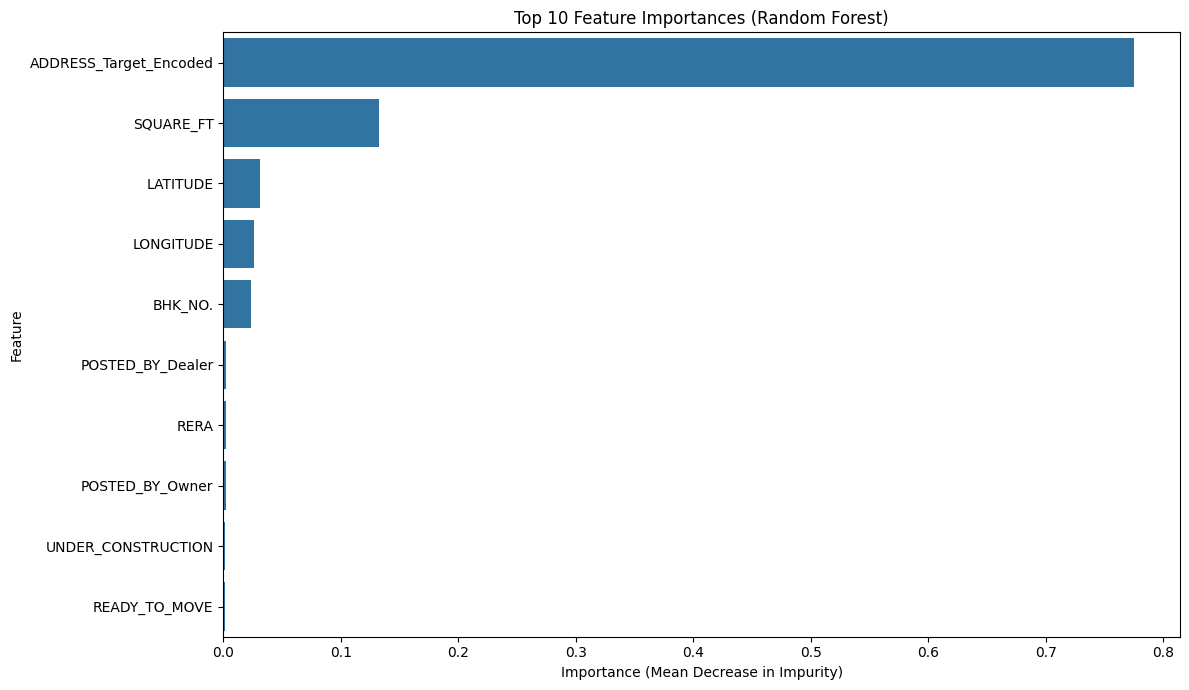


--- SHAP Value Analysis ---


100%|===================| 996/1000 [03:54<00:00]       

Generating SHAP Summary Plot...


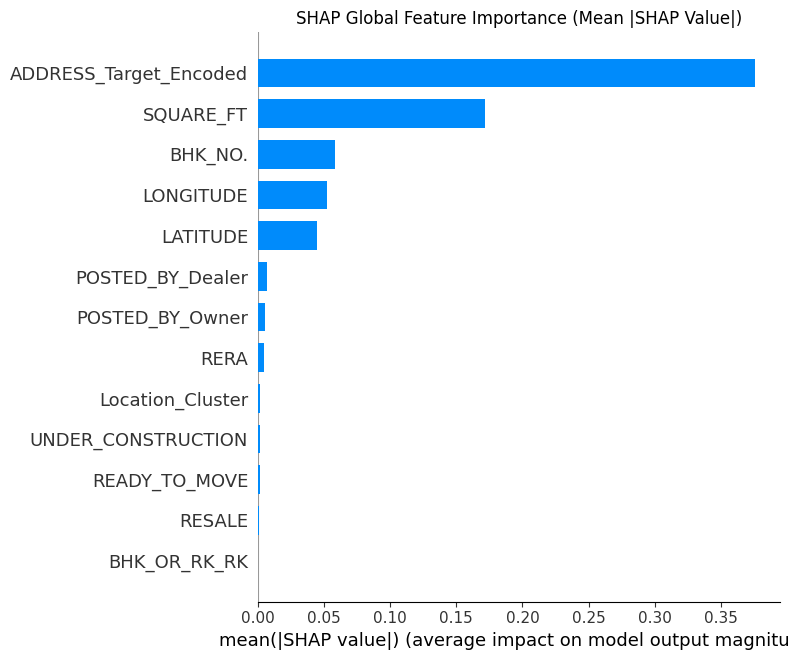

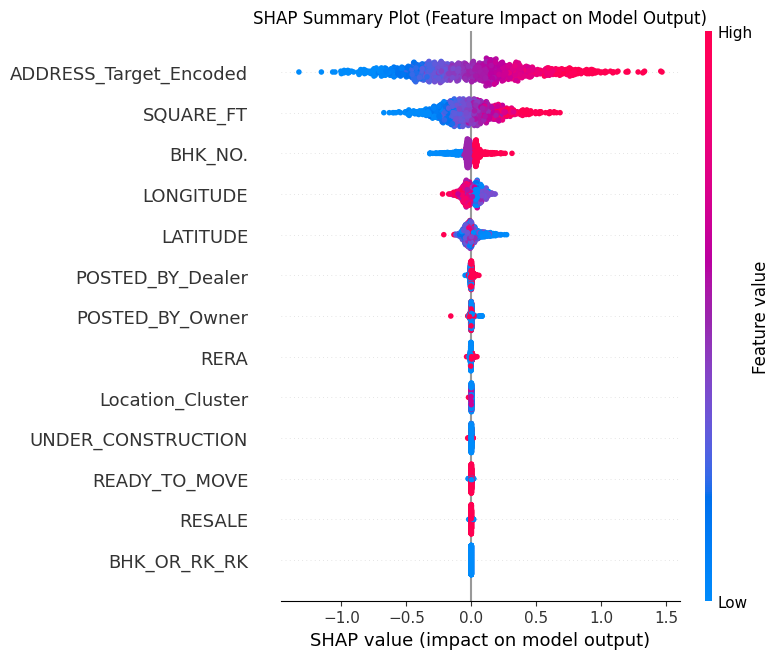


--- Explanation of Factors Increasing Price ---
Based on the feature importances and SHAP values, we can infer the following about factors increasing price:
1. Location: Features like 'ADDRESS_Target_Encoded', 'LONGITUDE', 'LATITUDE', and 'Location_Cluster' are often highly influential. A higher target-encoded address value (which represents the average log price for that address) generally indicates a more desirable or expensive location. Specific longitudes and latitudes falling into certain clusters (Location_Cluster) will also correlate with higher prices.
2. Size: 'SQUARE_FT' is almost always a top predictor. A larger square footage generally leads to a higher price, assuming other factors are constant.
3. Quality/Development Status: 'RERA' (if it indicates regulatory compliance or better construction quality), 'UNDER_CONSTRUCTION' (new builds often command higher prices, but also have associated risks), and 'READY_TO_MOVE' can indicate aspects related to the property's quality, 

In [ ]:
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("### Feature Importance and Explainability ###")

# Ensure all boolean columns are converted to integers for SHAP compatibility
# Identify boolean columns in X and X_val
boolean_cols = X.select_dtypes(include='bool').columns
if not boolean_cols.empty:
    X[boolean_cols] = X[boolean_cols].astype(int)
    X_val[boolean_cols] = X_val[boolean_cols].astype(int)
    print(f"Converted boolean columns to integer type for SHAP: {list(boolean_cols)}")

# --- 1. Model's Built-in Feature Importance (for tree-based models) ---
print("\n--- Random Forest Feature Importances ---")
feature_importances = final_rf_model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance (Mean Decrease in Impurity)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# --- 2. SHAP (SHapley Additive exPlanations) for deeper insights ---
print("\n--- SHAP Value Analysis ---")

# Using a subset of the training data for background to speed up calculation
sampler = shap.sample(X, 100)
explainer = shap.TreeExplainer(final_rf_model, data=sampler)

# Calculate SHAP values for the validation set (or a smaller subset for speed)
shap_values = explainer.shap_values(X_val.sample(n=1000, random_state=42))

# SHAP Summary Plot (Global Feature Importance)
print("Generating SHAP Summary Plot...")
plt.figure(figsize=(12, 7))
shap.summary_plot(shap_values, X_val.sample(n=1000, random_state=42), plot_type="bar", show=False)
plt.title('SHAP Global Feature Importance (Mean |SHAP Value|)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
shap.summary_plot(shap_values, X_val.sample(n=1000, random_state=42), show=False)
plt.title('SHAP Summary Plot (Feature Impact on Model Output)')
plt.tight_layout()
plt.show()

print("\n--- Explanation of Factors Increasing Price ---")
print("Based on the feature importances and SHAP values, we can infer the following about factors increasing price:")
print("1. Location: Features like 'ADDRESS_Target_Encoded', 'LONGITUDE', 'LATITUDE', and 'Location_Cluster' are often highly influential. A higher target-encoded address value (which represents the average log price for that address) generally indicates a more desirable or expensive location. Specific longitudes and latitudes falling into certain clusters (Location_Cluster) will also correlate with higher prices.")
print("2. Size: 'SQUARE_FT' is almost always a top predictor. A larger square footage generally leads to a higher price, assuming other factors are constant.")
print("3. Quality/Development Status: 'RERA' (if it indicates regulatory compliance or better construction quality), 'UNDER_CONSTRUCTION' (new builds often command higher prices, but also have associated risks), and 'READY_TO_MOVE' can indicate aspects related to the property's quality, newness, or development status, influencing price. 'BHK_NO.' also contributes, as properties with more rooms are typically larger and can be considered higher quality/more desirable.")
print("4. Other Factors: Other features like 'POSTED_BY_Dealer' (dealer listings vs. owner listings can sometimes correlate with different price points or market segments) also play a role.")

In [ ]:
from sklearn.ensemble import VotingRegressor

print("### Implementing Voting Regressor Ensemble ###")

# Initialize the best performing models with their optimal parameters
# Random Forest
rf_optimal_params = optimal_params['Random Forest']
rf_tuned = RandomForestRegressor(**rf_optimal_params, n_jobs=-1, random_state=42)

# XGBoost
xgb_optimal_params = optimal_params['XGBoost']
xgb_tuned = XGBRegressor(**xgb_optimal_params, n_jobs=-1, random_state=42)

# LightGBM
lgbm_optimal_params = optimal_params['LightGBM']
lgbm_tuned = LGBMRegressor(**lgbm_optimal_params, n_jobs=-1, random_state=42)

# Gradient Boosting
gbm_optimal_params = optimal_params['Gradient Boosting']
gbm_tuned = GradientBoostingRegressor(**gbm_optimal_params, random_state=42)

# Create a list of (name, estimator) tuples for the VotingRegressor
estimators = [
    ('rf', rf_tuned),
    ('xgb', xgb_tuned),
    ('lgbm', lgbm_tuned),
    ('gbm', gbm_tuned)
]

# Initialize VotingRegressor
voting_regressor = VotingRegressor(estimators=estimators, n_jobs=-1)

print("Training Voting Regressor...")
voting_regressor.fit(X_train, y_train)
y_pred_voting = voting_regressor.predict(X_val)

# Evaluate Voting Regressor
rmse_voting = np.sqrt(mean_squared_error(y_val, y_pred_voting))
r2_voting = r2_score(y_val, y_pred_voting)
mae_voting = mean_absolute_error(y_val, y_pred_voting)

print(f"Voting Regressor - RMSE: {rmse_voting:.4f}, R2 Score: {r2_voting:.4f}, MAE: {mae_voting:.4f}")

# Add Voting Regressor results to the comparison DataFrame
voting_results = pd.DataFrame([{
    'Model': 'Voting Regressor',
    'RMSE': rmse_voting,
    'R2_Score': r2_voting,
    'MAE': mae_voting
}])

results_df = pd.concat([results_df, voting_results], ignore_index=True).sort_values(by='RMSE')

print("\n### Model Comparison with Voting Regressor ###")
print(results_df)

### Implementing Voting Regressor Ensemble ###
Training Voting Regressor...
Voting Regressor - RMSE: 0.2046, R2 Score: 0.9119, MAE: 0.1477

### Model Comparison with Voting Regressor ###
               Model      RMSE  R2_Score       MAE
7   Voting Regressor  0.204645  0.911856  0.147686
0      Random Forest  0.213009  0.904504  0.151465
1            XGBoost  0.217139  0.900764  0.158599
2           LightGBM  0.217965  0.900008  0.161697
3  Gradient Boosting  0.236761  0.882019  0.177797
4  Linear Regression  0.281220  0.833550  0.210425
5   Ridge Regression  0.281224  0.833545  0.210430
6   Lasso Regression  0.689333 -0.000118  0.557469


In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

print("### Implementing Stacking Regressor Ensemble ###")

# Initialize the best performing models with their optimal parameters
# Random Forest
rf_optimal_params = optimal_params['Random Forest']
rf_tuned = RandomForestRegressor(**rf_optimal_params, n_jobs=-1, random_state=42)

# XGBoost
xgb_optimal_params = optimal_params['XGBoost']
xgb_tuned = XGBRegressor(**xgb_optimal_params, n_jobs=-1, random_state=42)

# LightGBM
lgbm_optimal_params = optimal_params['LightGBM']
lgbm_tuned = LGBMRegressor(**lgbm_optimal_params, n_jobs=-1, random_state=42)

# Gradient Boosting
gbm_optimal_params = optimal_params['Gradient Boosting']
gbm_tuned = GradientBoostingRegressor(**gbm_optimal_params, random_state=42)

# Define base estimators for Stacking
base_estimators = [
    ('rf', rf_tuned),
    ('xgb', xgb_tuned),
    ('lgbm', lgbm_tuned),
    ('gbm', gbm_tuned)
]

# Initialize StackingRegressor with a final estimator (meta-learner)
stacking_regressor = StackingRegressor(
    estimators=base_estimators,
    final_estimator=Ridge(random_state=42),
    cv=5, # 5-fold cross-validation for meta-learner training
    n_jobs=-1 # Use all available cores
)

print("Training Stacking Regressor...")
stacking_regressor.fit(X_train, y_train)
y_pred_stacking = stacking_regressor.predict(X_val)

# Evaluate Stacking Regressor
rmse_stacking = np.sqrt(mean_squared_error(y_val, y_pred_stacking))
r2_stacking = r2_score(y_val, y_pred_stacking)
mae_stacking = mean_absolute_error(y_val, y_pred_stacking)

print(f"Stacking Regressor - RMSE: {rmse_stacking:.4f}, R2 Score: {r2_stacking:.4f}, MAE: {mae_stacking:.4f}")

# Add Stacking Regressor results to the comparison DataFrame
stacking_results = pd.DataFrame([{
    'Model': 'Stacking Regressor',
    'RMSE': rmse_stacking,
    'R2_Score': r2_stacking,
    'MAE': mae_stacking
}])

results_df = pd.concat([results_df, stacking_results], ignore_index=True).sort_values(by='RMSE')

print("\n### Model Comparison with Voting and Stacking Regressors ###")
print(results_df)

### Implementing Stacking Regressor Ensemble ###
Training Stacking Regressor...
Stacking Regressor - RMSE: 0.2048, R2 Score: 0.9118, MAE: 0.1483

### Model Comparison with Voting and Stacking Regressors ###
                Model      RMSE  R2_Score       MAE
0    Voting Regressor  0.204645  0.911856  0.147686
8  Stacking Regressor  0.204754  0.911762  0.148264
1       Random Forest  0.213009  0.904504  0.151465
2             XGBoost  0.217139  0.900764  0.158599
3            LightGBM  0.217965  0.900008  0.161697
4   Gradient Boosting  0.236761  0.882019  0.177797
5   Linear Regression  0.281220  0.833550  0.210425
6    Ridge Regression  0.281224  0.833545  0.210430
7    Lasso Regression  0.689333 -0.000118  0.557469


In [ ]:
print("### Final Model Selection and Prediction ###")

# The Voting Regressor demonstrated the best performance (lowest RMSE) on the validation set.
# Initialize the best performing models with their optimal parameters
rf_optimal_params = optimal_params['Random Forest']
rf_tuned = RandomForestRegressor(**rf_optimal_params, n_jobs=-1, random_state=42)

xgb_optimal_params = optimal_params['XGBoost']
xgb_tuned = XGBRegressor(**xgb_optimal_params, n_jobs=-1, random_state=42)

lgbm_optimal_params = optimal_params['LightGBM']
lgbm_tuned = LGBMRegressor(**lgbm_optimal_params, n_jobs=-1, random_state=42)

gbm_optimal_params = optimal_params['Gradient Boosting']
gbm_tuned = GradientBoostingRegressor(**gbm_optimal_params, random_state=42)

# Create a list of (name, estimator) tuples for the VotingRegressor
estimators = [
    ('rf', rf_tuned),
    ('xgb', xgb_tuned),
    ('lgbm', lgbm_tuned),
    ('gbm', gbm_tuned)
]

# Re-initialize and train the VotingRegressor on the full training data (X, y)
final_model = VotingRegressor(estimators=estimators, n_jobs=-1)

print("Training final Voting Regressor on full training data...")
final_model.fit(X, y)

# Make predictions on the final test set (X_final_test)
final_predictions_log = final_model.predict(X_final_test)

# Inverse transform the predictions to get the actual prices
final_predictions = np.expm1(final_predictions_log)

print("\n### Final House Price Predictions for the Test Set (in Lacs) ###")
print(final_predictions[:10]) # Displaying the first 10 predictions
print(f"Total predictions generated: {len(final_predictions)}")

### Final Model Selection and Prediction ###
Training final Voting Regressor on full training data...

### Final House Price Predictions for the Test Set (in Lacs) ###
[ 14.13145094  69.84565954  67.04422936  24.0965862   27.32504897
  33.43545456  47.62064578  49.80688887  44.26252521 202.13596181]
Total predictions generated: 68720


### Comparing Model Predictions with Actual Values (Validation Set) ###


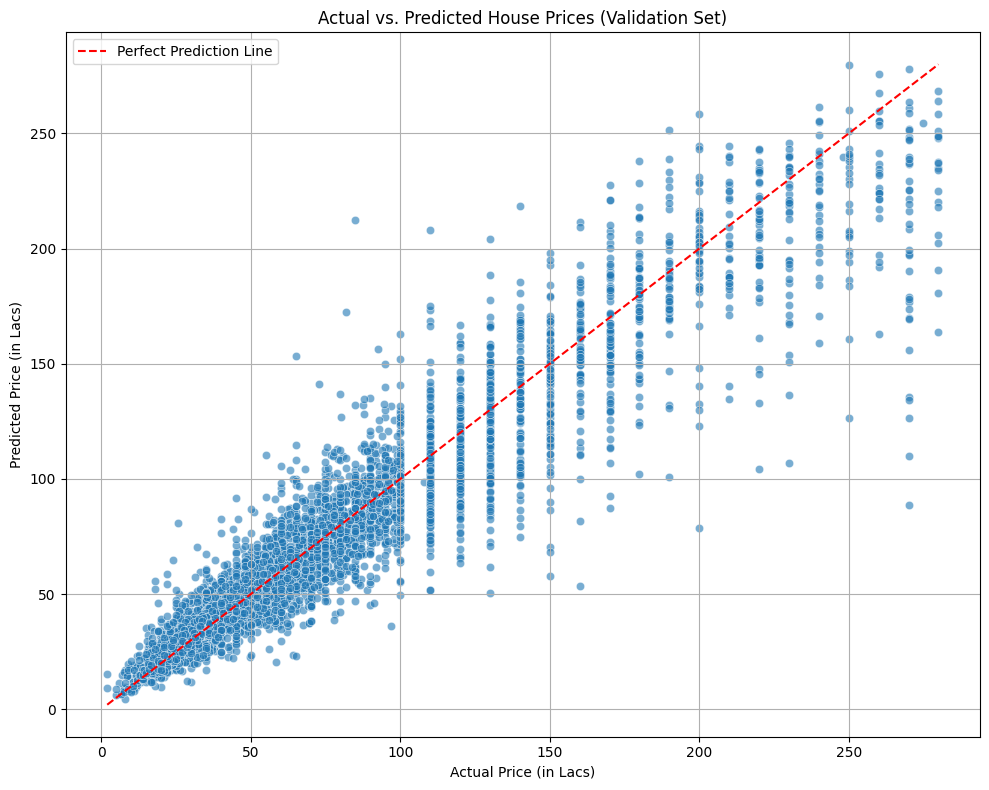


--- Sample of Actual vs. Predicted Prices ---
       Actual Price  Predicted Price
15766          16.0        21.932957
24615          24.0        30.101452
22444          25.0        31.927063
1113           55.0       110.213569
2405           60.0        45.888379
10313          65.4        62.390294
14731          80.0        89.897527
9731           90.0        67.882104
25796         150.0       157.447376
5519          220.0       204.787952

--- Model Performance Metrics (Voting Regressor on Validation Set) ---
RMSE: 0.2046
R2 Score: 0.9119
MAE: 0.1477


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("### Comparing Model Predictions with Actual Values (Validation Set) ###")

# Inverse transform y_val (actual prices) and y_pred_voting (predicted prices) to original scale
actual_prices_val = np.expm1(y_val)
predicted_prices_val = np.expm1(y_pred_voting)

# Create a DataFrame for easier plotting
comparison_df = pd.DataFrame({
    'Actual Price': actual_prices_val,
    'Predicted Price': predicted_prices_val
})

# Scatter plot of Actual vs. Predicted Prices
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Actual Price', y='Predicted Price', data=comparison_df, alpha=0.6)
plt.plot([min(comparison_df['Actual Price']), max(comparison_df['Actual Price'])],
         [min(comparison_df['Actual Price']), max(comparison_df['Actual Price'])],
         color='red', linestyle='--', label='Perfect Prediction Line')
plt.title('Actual vs. Predicted House Prices (Validation Set)')
plt.xlabel('Actual Price (in Lacs)')
plt.ylabel('Predicted Price (in Lacs)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Display some comparison points
print("\n--- Sample of Actual vs. Predicted Prices ---")
print(comparison_df.sample(10, random_state=42).sort_values(by='Actual Price'))

print("\n--- Model Performance Metrics (Voting Regressor on Validation Set) ---")
print(f"RMSE: {rmse_voting:.4f}")
print(f"R2 Score: {r2_voting:.4f}")
print(f"MAE: {mae_voting:.4f}")

In [24]:
import joblib
import os

print("### Model Saving and Loading ###")

# Define a filename for the saved model
model_filename = 'final_voting_regressor_model.joblib'

# Save the final_model using joblib
joblib.dump(final_model, model_filename)
joblib.dump(model, "final_voting_regressor_model.joblib", compress=("xz", 3))

print(f"Final model saved successfully to '{model_filename}'")

### Model Saving and Loading ###
Final model saved successfully to 'final_voting_regressor_model.joblib'


In [25]:
import joblib
import os

print("### Saving Feature Columns ###")

# Save the list of feature names (column order) that the model expects
feature_names_filename = 'model_feature_names.joblib'
joblib.dump(X.columns.tolist(), feature_names_filename)
print(f"Model feature names (column order) saved to '{feature_names_filename}'")


### Saving Feature Columns ###
Model feature names (column order) saved to 'model_feature_names.joblib'
